# QR Code Inspection System — Evaluation Notebook
### Method: Retinex + Zero-DCE Hybrid Preprocessing
**Aligned with Proposal: Section 2.4.1 (Image Preprocessing) & Table 2.1 (Before vs After)**

## 1. Import & Setup

In [1]:
import cv2
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pyzbar import pyzbar

## 2. Threshold Settings

In [2]:
# =========================
# THRESHOLD SETTINGS
# =========================
BRIGHTNESS_THRESHOLD = 90.0
BLUR_THRESHOLD       = 40.0
CONTRAST_THRESHOLD   = 25.0
ANGLE_PASS_MAX       = 15
ANGLE_REJECT_MAX     = 30

# Zero-DCE process size (resize before CNN for speed)
ZERODCE_PROCESS_SIZE = (320, 240)

# Dataset paths — update to your actual paths
FOLDER_PATH  = r"D:\UNIKL\FYP2\QR_data\train\images"
LABELS_PATH  = r"D:\UNIKL\FYP2\QR_data\train\labels"
WEIGHTS_PATH = r"zero_dce.pth"   # place zero_dce.pth in same folder as this notebook

## 3. Zero-DCE Model Definition

In [3]:
class ZeroDCE(nn.Module):
    """
    Zero-Reference Deep Curve Estimation (CVPR 2020)
    Lightweight 7-layer CNN for low-light image enhancement.
    Input:  (1, 3, H, W) float32 RGB image [0,1]
    Output: (1, 3, H, W) enhanced image [0,1]
    """
    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)
        n = 32
        self.e_conv1 = nn.Conv2d(3,   n,   3, 1, 1, bias=True)
        self.e_conv2 = nn.Conv2d(n,   n,   3, 1, 1, bias=True)
        self.e_conv3 = nn.Conv2d(n,   n,   3, 1, 1, bias=True)
        self.e_conv4 = nn.Conv2d(n,   n,   3, 1, 1, bias=True)
        self.e_conv5 = nn.Conv2d(n*2, n,   3, 1, 1, bias=True)
        self.e_conv6 = nn.Conv2d(n*2, n,   3, 1, 1, bias=True)
        self.e_conv7 = nn.Conv2d(n*2, 24,  3, 1, 1, bias=True)

    def forward(self, x):
        x1 = self.relu(self.e_conv1(x))
        x2 = self.relu(self.e_conv2(x1))
        x3 = self.relu(self.e_conv3(x2))
        x4 = self.relu(self.e_conv4(x3))
        x5 = self.relu(self.e_conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.e_conv6(torch.cat([x2, x5], 1)))
        x_r = torch.tanh(self.e_conv7(torch.cat([x1, x6], 1)))
        r = torch.split(x_r, 3, dim=1)
        out = x
        for ri in r:
            out = out + ri * (out - out ** 2)
        return out


_zero_dce_model = None

def get_zero_dce():
    global _zero_dce_model
    if _zero_dce_model is None:
        _zero_dce_model = ZeroDCE()
        if os.path.exists(WEIGHTS_PATH):
            _zero_dce_model.load_state_dict(
                torch.load(WEIGHTS_PATH, map_location="cpu")
            )
            print(f"Zero-DCE: weights loaded from {WEIGHTS_PATH}")
        else:
            print(f"WARNING: zero_dce.pth not found at {WEIGHTS_PATH}")
            print("Zero-DCE will run with random weights (poor quality).")
        _zero_dce_model.eval()
    return _zero_dce_model


def apply_zero_dce(frame_bgr):
    """Run Zero-DCE on a BGR frame. Returns enhanced BGR frame (uint8)."""
    model = get_zero_dce()
    h_orig, w_orig = frame_bgr.shape[:2]
    small  = cv2.resize(frame_bgr, ZERODCE_PROCESS_SIZE)
    rgb    = cv2.cvtColor(small, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    tensor = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)
    with torch.inference_mode():
        enhanced = model(tensor)
    out = enhanced.squeeze().permute(1, 2, 0).numpy()
    out = np.clip(out * 255, 0, 255).astype(np.uint8)
    out = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
    return cv2.resize(out, (w_orig, h_orig))

## 4. Load Image

In [4]:
def load_image(path, max_size=1280):
    img = cv2.imread(path)
    if img is None:
        return None
    h, w = img.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img = cv2.resize(img, (int(w * scale), int(h * scale)),
                         interpolation=cv2.INTER_AREA)
    return img

## 5. Retinex + Preprocessing

In [5]:
def simple_retinex(img, sigma=15):
    img  = img.astype(np.float32) + 1.0
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    retinex = np.log(img) - np.log(blur)
    retinex = cv2.normalize(retinex, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(retinex)


def preprocess_image(img):
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = float(np.mean(gray))

    clahe      = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    clahe_img  = clahe.apply(gray)
    retinex_img = simple_retinex(gray, sigma=15)

    if brightness < BRIGHTNESS_THRESHOLD:
        enhanced = retinex_img
        method   = "RETINEX"
    else:
        enhanced = clahe_img
        method   = "CLAHE"

    _, otsu = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    adaptive = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 5
    )

    return {
        "gray":       gray,
        "enhanced":   enhanced,
        "clahe":      clahe_img,
        "retinex":    retinex_img,
        "otsu":       otsu,
        "adaptive":   adaptive,
        "brightness": brightness,
        "method":     method
    }

## 6. Quality Inspection

In [6]:
def quality_inspection(preprocessed):
    enhanced = preprocessed["enhanced"]
    blur     = cv2.Laplacian(enhanced, cv2.CV_64F).var()
    contrast = float(enhanced.max() - enhanced.min())
    return {"blur": float(blur), "contrast": contrast}


def decision_logic_1(quality_metrics):
    if quality_metrics["blur"] < BLUR_THRESHOLD:
        return "REJECT", "BLUR"
    if quality_metrics["contrast"] < CONTRAST_THRESHOLD:
        return "REJECT", "LOW_CONTRAST"
    return "PASS", "QUALITY_OK"

## 7. QR Detection & Decode

In [7]:
def estimate_qr_angle(decoded_obj):
    pts = decoded_obj.polygon
    if pts is None or len(pts) < 2:
        return None
    p1, p2 = pts[0], pts[1]
    angle = np.degrees(np.arctan2(p2.y - p1.y, p2.x - p1.x))
    if angle > 90:  angle -= 180
    elif angle < -90: angle += 180
    return float(angle)


def try_decode(img):
    # 1. pyzbar
    decoded = pyzbar.decode(img)
    if decoded:
        obj = decoded[0]
        return {
            "qr_found": True,
            "qr_data":  obj.data.decode("utf-8", errors="ignore"),
            "angle":    estimate_qr_angle(obj),
            "decode_method": "PYZBAR"
        }
    # 2. OpenCV
    detector = cv2.QRCodeDetector()
    try:
        text, points, _ = detector.detectAndDecode(img)
        if text:
            return {"qr_found": True, "qr_data": text,
                    "angle": None, "decode_method": "OPENCV_QR"}
    except:
        pass
    return None


def qr_detection(preprocessed):
    candidates = []
    gray        = preprocessed["gray"]
    enhanced    = preprocessed["enhanced"]
    otsu        = preprocessed["otsu"]
    clahe_img   = preprocessed["clahe"]
    retinex_img = preprocessed["retinex"]

    # === BASIC CANDIDATES ===
    candidates.append(("GRAY",    gray))
    candidates.append(("ENHANCED", enhanced))
    candidates.append(("OTSU",    otsu))
    candidates.append(("CLAHE",   clahe_img))
    candidates.append(("RETINEX", retinex_img))

    # === INVERTED ===
    candidates.append(("INV_GRAY",     cv2.bitwise_not(gray)))
    candidates.append(("INV_ENHANCED", cv2.bitwise_not(enhanced)))
    candidates.append(("INV_OTSU",     cv2.bitwise_not(otsu)))

    # === SHARPENED ===
    def sharpen(img):
        blurred = cv2.GaussianBlur(img, (0, 0), 3)
        return cv2.addWeighted(img, 1.5, blurred, -0.5, 0)
    candidates.append(("SHARPENED", sharpen(enhanced)))

    # === DENOISED ===
    denoised = cv2.fastNlMeansDenoising(gray, h=10)
    candidates.append(("DENOISED", denoised))
    _, denoised_otsu = cv2.threshold(denoised, 0, 255,
                                     cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    candidates.append(("DENOISED_OTSU", denoised_otsu))

    # === MULTIPLE ADAPTIVE BLOCK SIZES ===
    for block_size in [11, 21, 31, 51]:
        adap = cv2.adaptiveThreshold(enhanced, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, block_size, 5)
        candidates.append((f"ADAPTIVE_{block_size}", adap))

    # === UPSCALED CANDIDATES ===
    for name, img in [("GRAY", gray), ("ENHANCED", enhanced),
                      ("OTSU", otsu), ("CLAHE", clahe_img)]:
        up2 = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
        candidates.append((f"{name}_UP2", up2))
        up3 = cv2.resize(img, None, fx=3.0, fy=3.0, interpolation=cv2.INTER_CUBIC)
        candidates.append((f"{name}_UP3", up3))

    # === ROTATION CANDIDATES ===
    for angle in [-45, -30, -20, -15, -10, -5, 5, 10, 15, 20, 30, 45]:
        h, w = enhanced.shape[:2]
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        rotated = cv2.warpAffine(enhanced, M, (w, h),
                                 borderMode=cv2.BORDER_REPLICATE)
        candidates.append((f"ROT_{angle}", rotated))
        up = cv2.resize(rotated, None, fx=2.0, fy=2.0,
                        interpolation=cv2.INTER_CUBIC)
        candidates.append((f"ROT_{angle}_UP2", up))

    # === TRY ALL CANDIDATES ===
    for method_name, img in candidates:
        result = try_decode(img)
        if result is not None:
            result["decode_method"] = method_name + "_" + result["decode_method"]
            return result

    return {
        "qr_found": False, "qr_data": None,
        "angle": None, "verdict": "REJECT",
        "reason": "no_qr", "decode_method": "FAILED_ALL"
    }


def decision_logic_2(qr_result):
    if qr_result["qr_found"]:
        return "PASS", "QR_DETECTED"
    return "NO_QR", "QR_NOT_DETECTED"

## 8. Run Dataset

In [8]:
def run_dataset(folder):
    results = []
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        if not os.path.isfile(path):
            continue
        t0  = time.perf_counter()
        img = load_image(path)
        if img is None:
            continue
        prep           = preprocess_image(img)
        quality_metrics = quality_inspection(prep)
        quality_status, quality_reason = decision_logic_1(quality_metrics)
        qr_result      = qr_detection(prep)
        qr_status, qr_reason = decision_logic_2(qr_result)
        latency_ms     = (time.perf_counter() - t0) * 1000.0

        results.append({
            "file":           file,
            "brightness":     round(prep["brightness"], 2),
            "method":         prep["method"],
            "blur":           round(quality_metrics["blur"], 2),
            "contrast":       round(quality_metrics["contrast"], 2),
            "quality_status": quality_status,
            "quality_reason": quality_reason,
            "angle":          None if qr_result["angle"] is None else round(qr_result["angle"], 2),
            "qr_found":       qr_result["qr_found"],
            "qr_data":        qr_result["qr_data"],
            "decode_method":  qr_result["decode_method"],
            "qr_status":      qr_status,
            "qr_reason":      qr_reason,
            "latency_ms":     round(latency_ms, 2)
        })
    return pd.DataFrame(results)

## 9. Single Image Test

=== QUALITY RESULT ===
Blur    : 410.02
Contrast: 255.0
Status  : PASS
Reason  : QUALITY_OK

=== QR DETECTION RESULT ===
QR Found: True
QR Data : Version 2 QR Code Test Image
Angle   : 1.3639275316029187
Status  : PASS
Reason  : QR_DETECTED


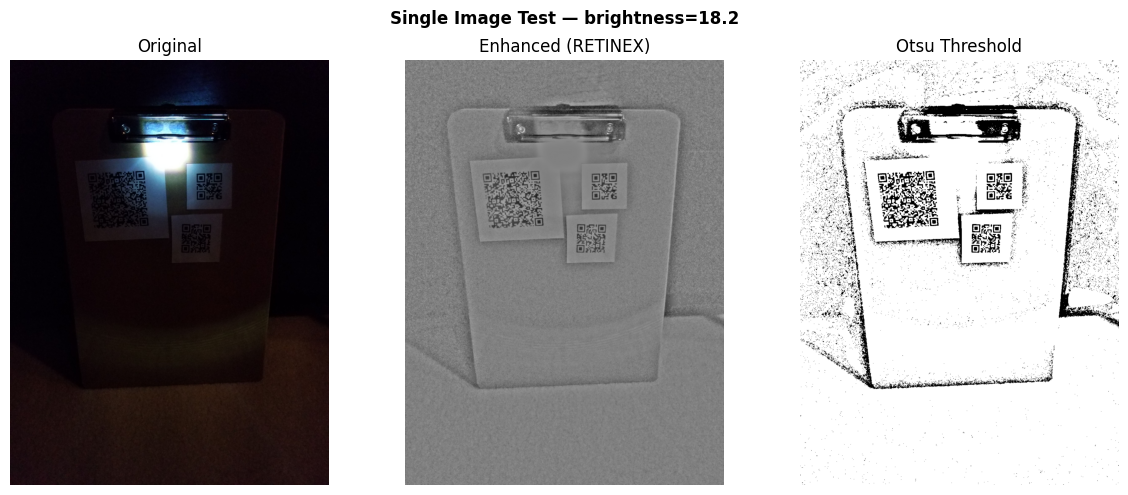

In [9]:
test_path = r"D:\UNIKL\FYP2\QR_data\train\images\spotsimage007.jpg"

img = load_image(test_path)

if img is None:
    print("Image not found!")
else:
    prep            = preprocess_image(img)
    quality_metrics = quality_inspection(prep)
    quality_status, quality_reason = decision_logic_1(quality_metrics)
    qr_result       = qr_detection(prep)
    qr_status, qr_reason = decision_logic_2(qr_result)

    print("=== QUALITY RESULT ===")
    print("Blur    :", round(quality_metrics["blur"], 2))
    print("Contrast:", round(quality_metrics["contrast"], 2))
    print("Status  :", quality_status)
    print("Reason  :", quality_reason)

    print("\n=== QR DETECTION RESULT ===")
    print("QR Found:", qr_result["qr_found"])
    print("QR Data :", qr_result["qr_data"])
    print("Angle   :", qr_result["angle"])
    print("Status  :", qr_status)
    print("Reason  :", qr_reason)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(prep["enhanced"], cmap="gray")
    plt.title(f"Enhanced ({prep['method']})")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(prep["otsu"], cmap="gray")
    plt.title("Otsu Threshold")
    plt.axis("off")
    plt.suptitle(f"Single Image Test — brightness={prep['brightness']:.1f}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 10. Run Dataset & Display Results

In [10]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

df = run_dataset(FOLDER_PATH)
display(df)

,file,brightness,method,blur,contrast,quality_status,quality_reason,angle,qr_found,qr_data,decode_method,qr_status,qr_reason,latency_ms
0,blurredimage001.jpg,114.17,CLAHE,116.29,246.0,PASS,QUALITY_OK,5.68,True,"{""lastNode"":""OAK5"",""cids"":{""pkey"":""17122710363...",GRAY_PYZBAR,PASS,QR_DETECTED,247.65
1,blurredimage002.jpg,139.34,CLAHE,1241.95,249.0,PASS,QUALITY_OK,22.42,True,http://www.lonelyplanet.com/,RETINEX_PYZBAR,PASS,QR_DETECTED,561.83
2,blurredimage005.jpg,150.18,CLAHE,133.57,255.0,PASS,QUALITY_OK,85.22,True,ABC 123456789 ABC 123456789 ABC 123456789 ABC ...,SHARPENED_PYZBAR,PASS,QR_DETECTED,1430.99
3,blurredimage017.jpg,36.33,RETINEX,154.68,255.0,PASS,QUALITY_OK,2.08,True,Version 2 QR Code Test Image,GRAY_PYZBAR,PASS,QR_DETECTED,599.21
4,blurredimage018.jpg,35.92,RETINEX,144.73,255.0,PASS,QUALITY_OK,NaN,False,None,FAILED_ALL,NO_QR,QR_NOT_DETECTED,9529.79
5,blurredimage019.jpg,35.89,RETINEX,128.19,255.0,PASS,QUALITY_OK,NaN,False,None,FAILED_ALL,NO_QR,QR_NOT_DETECTED,9312.56
6,blurredimage027.jpg,72.14,RETINEX,62.89,255.0,PASS,QUALITY_OK,29.94,True,http://www.boschautoparts.com/qr/icon.aspx,CLAHE_UP3_PYZBAR,PASS,QR_DETECTED,3053.87
7,blurredimage032.jpg,143.50,CLAHE,157.41,249.0,PASS,QUALITY_OK,83.35,True,http://www.bestekmall.com/,GRAY_PYZBAR,PASS,QR_DETECTED,587.28
8,blurredimage033.jpg,144.75,CLAHE,145.27,247.0,PASS,QUALITY_OK,83.31,True,http://www.bestekmall.com/,GRAY_PYZBAR,PASS,QR_DETECTED,581.77
9,blurredimage034.jpg,179.25,CLAHE,108.29,244.0,PASS,QUALITY_OK,27.33,True,"{""lastNode"":""OAK5"",""cids"":{""pkey"":""18041019482...",GRAY_PYZBAR,PASS,QR_DETECTED,630.38


## 11. Summary of Result 1 — Quality Inspection

In [11]:
print("QUALITY INSPECTION RESULT")
print(df["quality_status"].value_counts())
print("\nQUALITY REASON")
print(df["quality_reason"].value_counts())

QUALITY INSPECTION RESULT
quality_status
PASS    200
Name: count, dtype: int64

QUALITY REASON
quality_reason
QUALITY_OK    200
Name: count, dtype: int64


## 12. Summary of Result 2 — QR Detection

In [12]:
print("QR DETECTION RESULT")
print(df["qr_status"].value_counts())
print("\nQR DETECTION REASON")
print(df["qr_reason"].value_counts())

QR DETECTION RESULT
qr_status
PASS     166
NO_QR     34
Name: count, dtype: int64

QR DETECTION REASON
qr_reason
QR_DETECTED        166
QR_NOT_DETECTED     34
Name: count, dtype: int64


## 13. Final Combined Result

In [13]:
df["final_result"] = df.apply(
    lambda row: "PASS"
    if row["quality_status"] == "PASS" and row["qr_status"] == "PASS"
    else "REJECT",
    axis=1
)

df["final_reason"] = df.apply(
    lambda row: row["quality_reason"] if row["quality_status"] != "PASS"
    else row["qr_reason"],
    axis=1
)

total        = len(df)
pass_count   = (df["final_result"] == "PASS").sum()
reject_count = (df["final_result"] == "REJECT").sum()

print("=== FINAL RESULT SUMMARY ===")
print(df["final_result"].value_counts())
print("\n=== FINAL REASON SUMMARY ===")
print(df["final_reason"].value_counts())
print("\n=== FINAL PERFORMANCE ===")
print(f"Total Images : {total}")
print(f"PASS         : {pass_count} ({pass_count/total*100:.2f}%)")
print(f"REJECT       : {reject_count} ({reject_count/total*100:.2f}%)")

=== FINAL RESULT SUMMARY ===
final_result
PASS      166
REJECT     34
Name: count, dtype: int64

=== FINAL REASON SUMMARY ===
final_reason
QR_DETECTED        166
QR_NOT_DETECTED     34
Name: count, dtype: int64

=== FINAL PERFORMANCE ===
Total Images : 200
PASS         : 166 (83.00%)
REJECT       : 34 (17.00%)


## 14. Save CSV

In [14]:
df.to_csv("results_AI_with_visual.csv", index=False)
print("Saved to results_AI_with_visual.csv")

Saved to results_AI_with_visual.csv


## 15. Evaluation Metrics (Ground Truth vs Prediction)

In [15]:
def annotation_label(filename):
    name       = os.path.splitext(filename)[0]
    label_file = os.path.join(LABELS_PATH, name + ".txt")
    if not os.path.exists(label_file):
        return "NO_QR"
    with open(label_file, "r") as f:
        lines = f.readlines()
    if len(lines) > 0 and any(line.strip() for line in lines):
        return "PASS"
    return "NO_QR"


df["actual_label"] = df["file"].apply(annotation_label)

y_true     = df["actual_label"]
y_pred     = df["final_result"]
y_true_bin = y_true.apply(lambda x: 1 if x == "PASS" else 0)
y_pred_bin = y_pred.apply(lambda x: 1 if x == "PASS" else 0)

TP = ((y_true_bin == 1) & (y_pred_bin == 1)).sum()
TN = ((y_true_bin == 0) & (y_pred_bin == 0)).sum()
FP = ((y_true_bin == 0) & (y_pred_bin == 1)).sum()
FN = ((y_true_bin == 1) & (y_pred_bin == 0)).sum()
total     = TP + TN + FP + FN
accuracy  = (TP + TN) / total if total > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score  = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0
fpr       = FP / (FP + TN) if (FP + TN) > 0 else 0
avg_lat   = df["latency_ms"].mean()

print("=== CHECK LABELS ===")
print("Actual Label:", df["actual_label"].unique())
print("Prediction  :", df["final_result"].unique())

print("\n=== CONFUSION MATRIX ===")
print(f"TP (Correct PASS)  : {TP}")
print(f"TN (Correct NO_QR) : {TN}")
print(f"FP (False PASS)    : {FP}")
print(f"FN (Missed QR)     : {FN}")

print("\n=== METRICS ===")
print(f"Accuracy            : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1_score:.4f}")
print(f"False Positive Rate : {fpr:.4f}")
print(f"Avg Latency (ms)    : {avg_lat:.2f}")

=== CHECK LABELS ===
Actual Label: ['PASS' 'NO_QR']
Prediction  : ['PASS' 'REJECT']

=== CONFUSION MATRIX ===
TP (Correct PASS)  : 148
TN (Correct NO_QR) : 7
FP (False PASS)    : 18
FN (Missed QR)     : 27

=== METRICS ===
Accuracy            : 0.7750  (77.50%)
Precision           : 0.8916
Recall              : 0.8457
F1 Score            : 0.8680
False Positive Rate : 0.7200
Avg Latency (ms)    : 2568.81


---
## 16. Visual Comparison of Preprocessing Outputs
### Aligned with Proposal — Section 2.4.1 & Table 2.1 (Before vs After Image Preprocessing)

This section shows:
- **Original vs Retinex-Enhanced** — for dark images (brightness 50–90)
- **Original vs Zero-DCE-Enhanced** — for very dark images (brightness < 50)

### 16.1 Original vs Retinex-Enhanced (Dark Images)

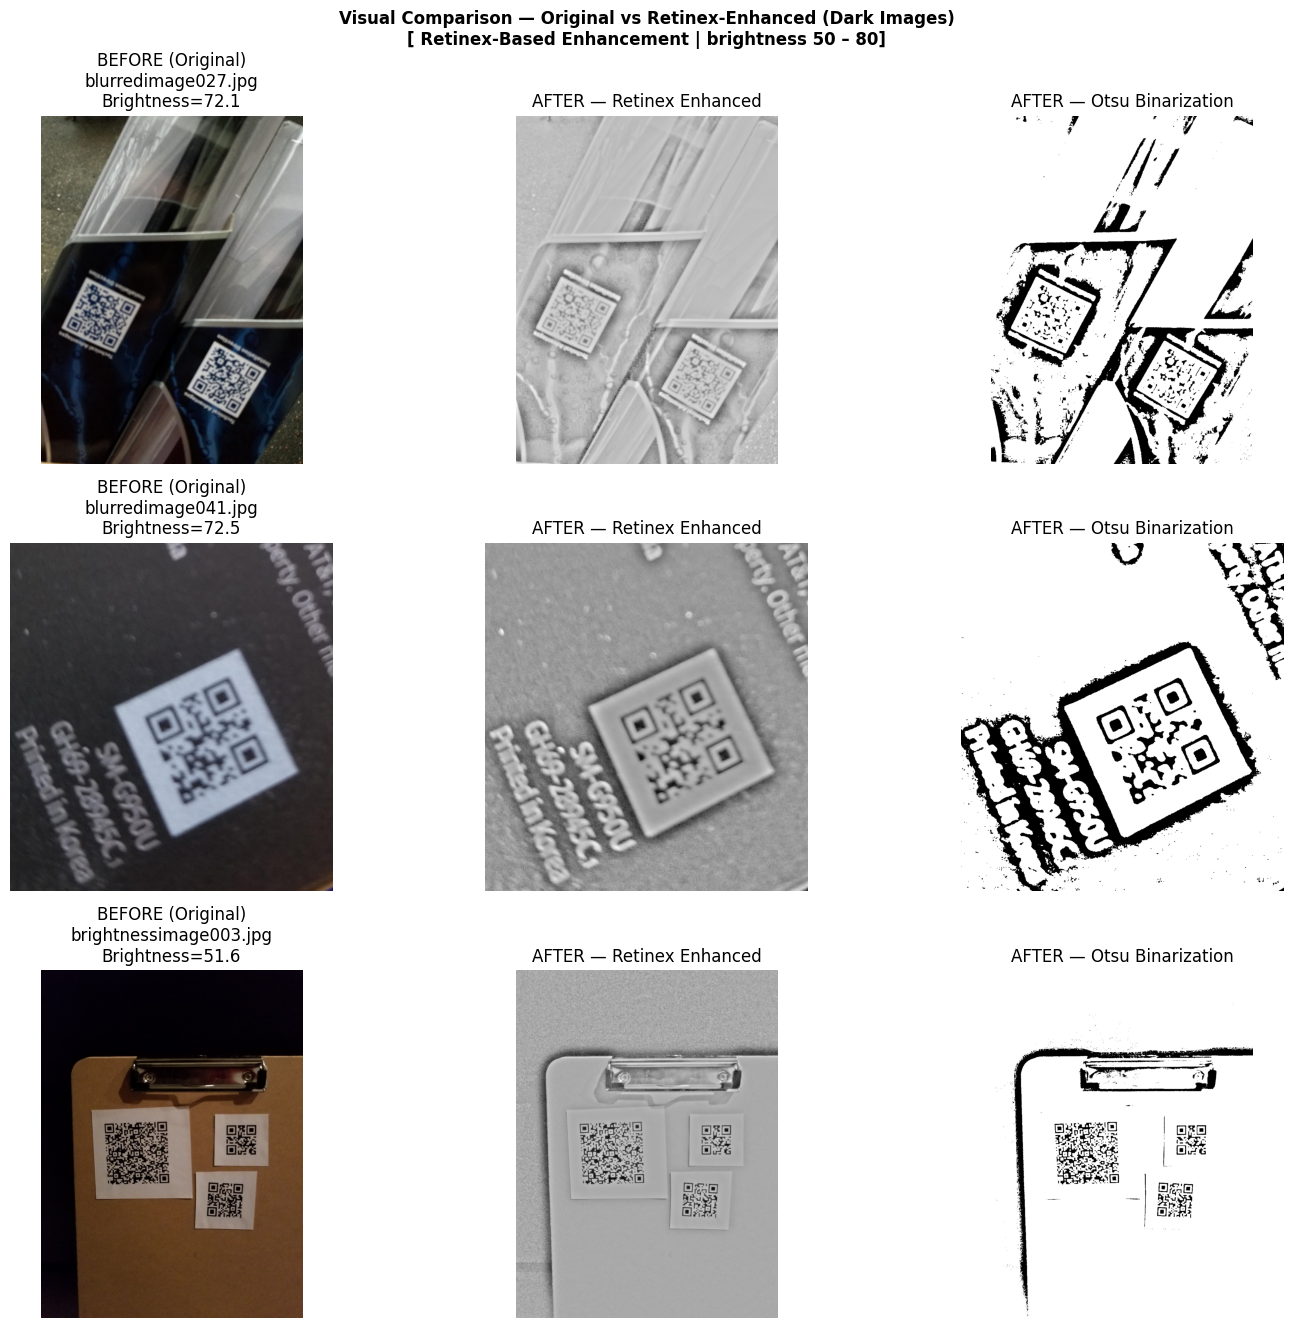

Saved: comparison_retinex.png (3 examples)


In [16]:
# ============================================================
# VISUAL COMPARISON — Original vs Retinex (dark images)
# Proposal ref: Section 2.4.1, Retinex-Based Enhancement
# Brightness range: 50 ≤ brightness < BRIGHTNESS_THRESHOLD
# ============================================================

retinex_examples = []   # collect up to 3 examples
MAX_EXAMPLES     = 3

for file in os.listdir(FOLDER_PATH):
    if len(retinex_examples) >= MAX_EXAMPLES:
        break
    if not file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        continue
    path = os.path.join(FOLDER_PATH, file)
    img  = load_image(path)
    if img is None:
        continue
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = float(np.mean(gray))
    if 50 <= brightness < BRIGHTNESS_THRESHOLD:
        retinex_examples.append((file, img, brightness))


if retinex_examples:
    n   = len(retinex_examples)
    fig, axes = plt.subplots(n, 3, figsize=(15, 4.5 * n))
    if n == 1:
        axes = [axes]   # make iterable

    fig.suptitle(
        "Visual Comparison — Original vs Retinex-Enhanced (Dark Images)\n"
        "[ Retinex-Based Enhancement | brightness 50 – 80]",
        fontsize=12, fontweight="bold"
    )

    for i, (fname, img, brightness) in enumerate(retinex_examples):
        gray        = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        retinex_out = simple_retinex(gray, sigma=15)
        _, otsu_out = cv2.threshold(retinex_out, 0, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        axes[i][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f"BEFORE (Original)\n{fname}\nBrightness={brightness:.1f}")
        axes[i][0].axis("off")

        axes[i][1].imshow(retinex_out, cmap="gray")
        axes[i][1].set_title("AFTER — Retinex Enhanced")
        axes[i][1].axis("off")

        axes[i][2].imshow(otsu_out, cmap="gray")
        axes[i][2].set_title("AFTER — Otsu Binarization")
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.savefig("comparison_retinex.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: comparison_retinex.png ({len(retinex_examples)} examples)")

else:
    print(f"No dark images (brightness 50–{BRIGHTNESS_THRESHOLD}) found in dataset.")
    print("Tip: Lower BRIGHTNESS_THRESHOLD or artificially darken an image:")
    print("  dark_img = cv2.convertScaleAbs(img, alpha=0.5, beta=0)")

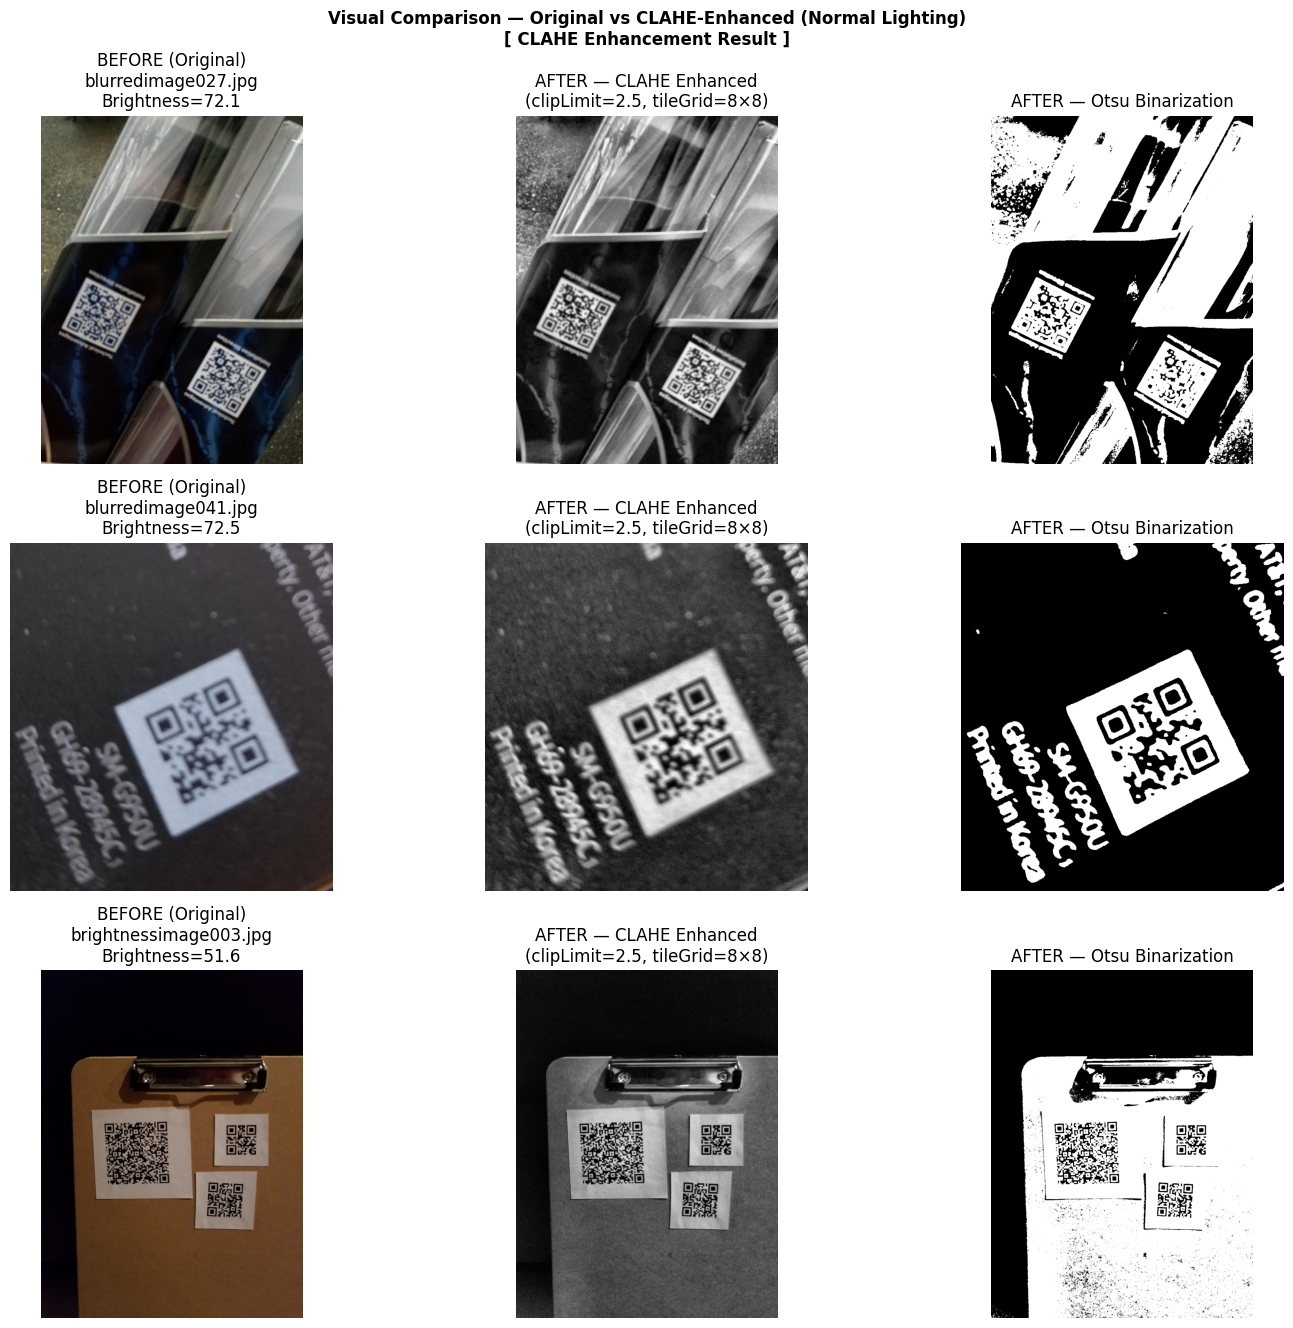

Saved: figure4_2_clahe_comparison.png (3 examples)


In [17]:
# ============================================================
# VISUAL COMPARISON — Original vs CLAHE (Normal Lighting)
# Report ref: Section 4.3.2, CLAHE Enhancement Result
# Uses same images as Figure 4.3 (retinex_examples)
# ============================================================
# Run AFTER the Retinex figure cell (retinex_examples must exist)
# ============================================================

if retinex_examples:
    n   = len(retinex_examples)
    fig, axes = plt.subplots(n, 3, figsize=(15, 4.5 * n))
    if n == 1:
        axes = [axes]   # make iterable

    fig.suptitle(
        "Visual Comparison — Original vs CLAHE-Enhanced (Normal Lighting)\n"
        "[ CLAHE Enhancement Result ]",
        fontsize=12, fontweight="bold"
    )

    clahe_obj = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))

    for i, (fname, img, brightness) in enumerate(retinex_examples):
        gray        = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        clahe_out   = clahe_obj.apply(gray)
        _, otsu_out = cv2.threshold(clahe_out, 0, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        axes[i][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f"BEFORE (Original)\n{fname}\nBrightness={brightness:.1f}")
        axes[i][0].axis("off")

        axes[i][1].imshow(clahe_out, cmap="gray")
        axes[i][1].set_title("AFTER — CLAHE Enhanced\n(clipLimit=2.5, tileGrid=8×8)")
        axes[i][1].axis("off")

        axes[i][2].imshow(otsu_out, cmap="gray")
        axes[i][2].set_title("AFTER — Otsu Binarization")
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.savefig("figure4_2_clahe_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: figure4_2_clahe_comparison.png ({len(retinex_examples)} examples)")

else:
    print("retinex_examples is empty — run the Retinex figure cell first.")

### 16.2 Original vs Zero-DCE-Enhanced (Very Dark Images)

Zero-DCE will run with random weights (poor quality).


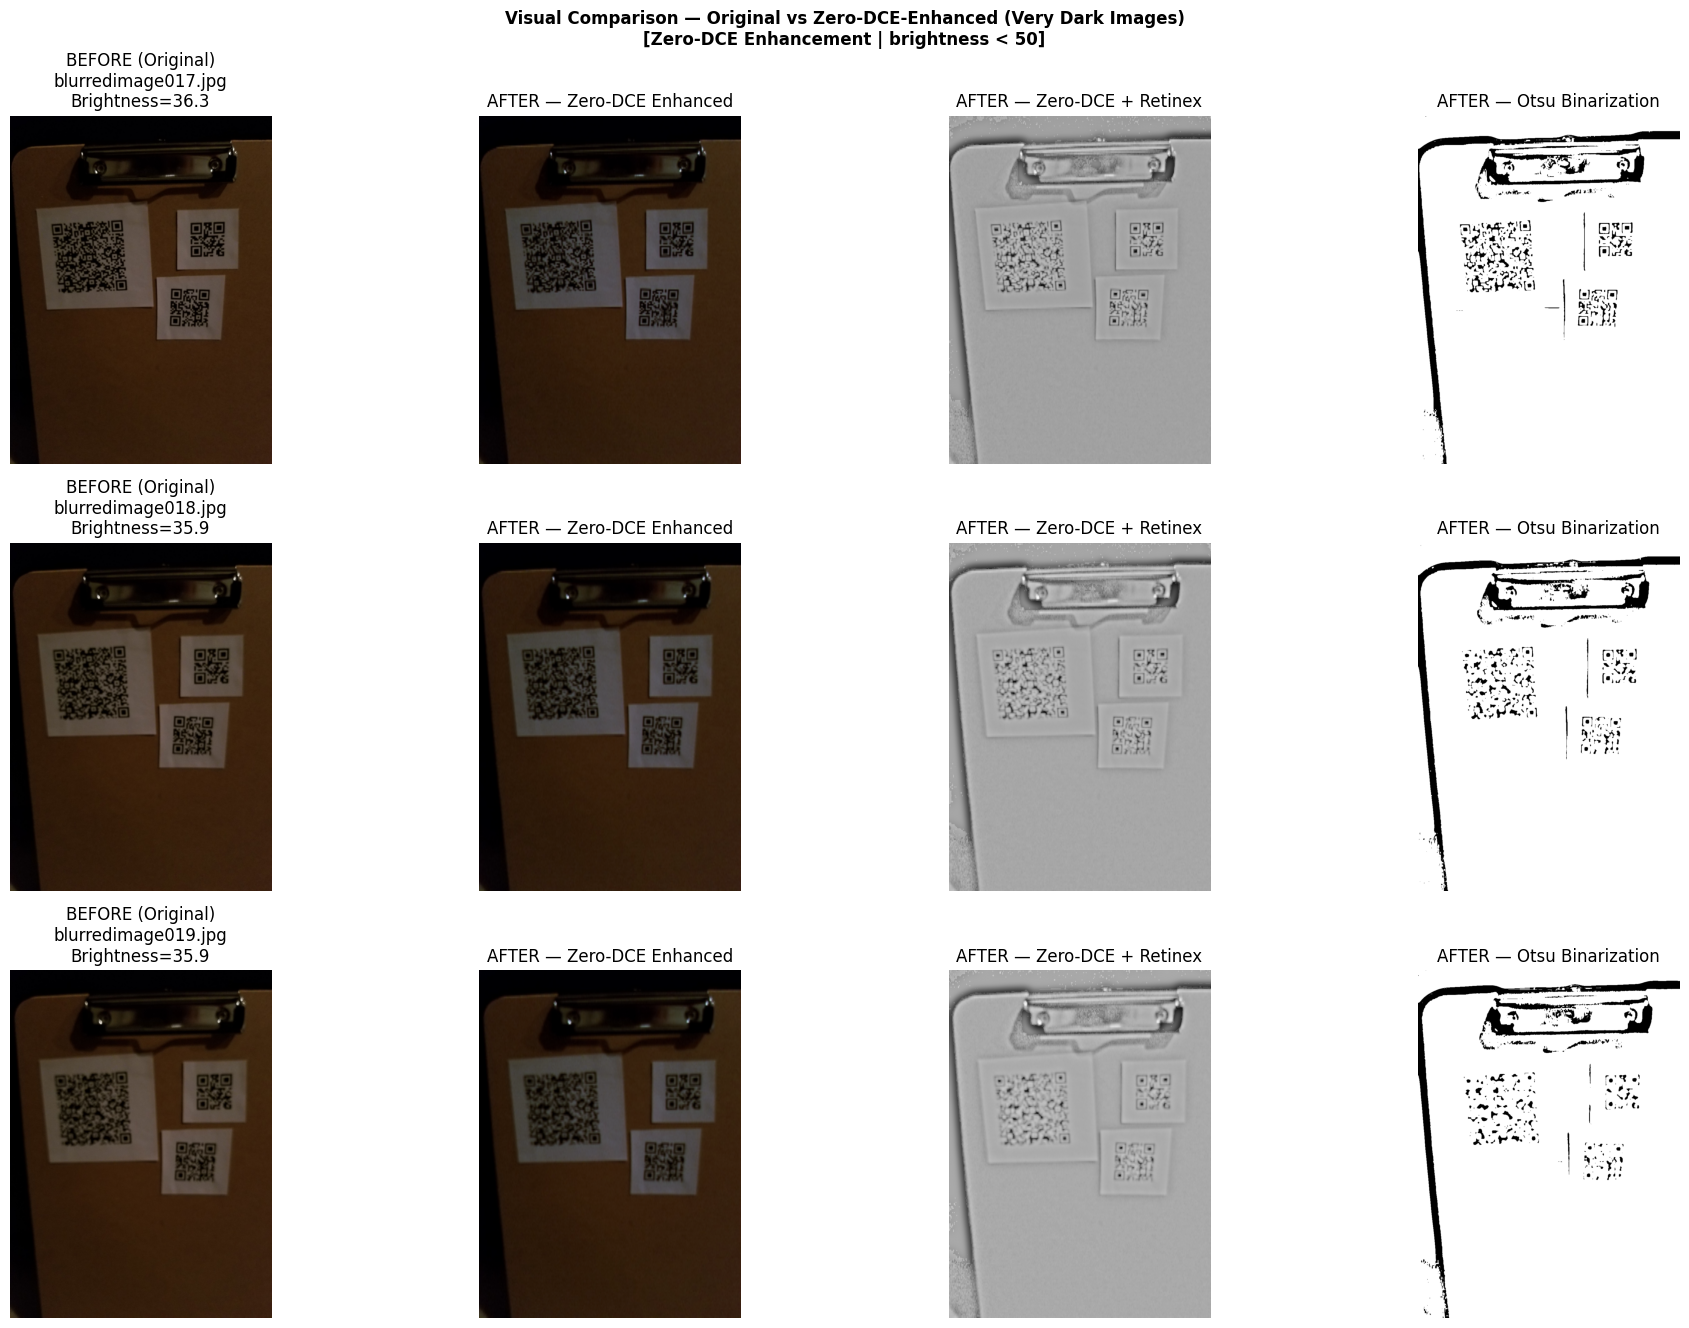

Saved: comparison_zerodce.png (3 examples)


In [18]:
# ============================================================
# VISUAL COMPARISON — Original vs Zero-DCE (very dark images)
# Proposal ref: Section 2.4.1, Zero-DCE Enhancement
# Brightness range: brightness < 50
# ============================================================

zerodce_examples = []   # collect up to 3 examples

for file in os.listdir(FOLDER_PATH):
    if len(zerodce_examples) >= MAX_EXAMPLES:
        break
    if not file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        continue
    path = os.path.join(FOLDER_PATH, file)
    img  = load_image(path)
    if img is None:
        continue
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = float(np.mean(gray))
    if brightness < 50:
        zerodce_examples.append((file, img, brightness))


# If no real very-dark images exist, create artificial ones for demo
if not zerodce_examples:
    print("No very dark images (brightness < 50) found.")
    print("Creating artificially darkened samples for demonstration...\n")
    count = 0
    for file in os.listdir(FOLDER_PATH):
        if count >= MAX_EXAMPLES:
            break
        if not file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            continue
        path = os.path.join(FOLDER_PATH, file)
        img  = load_image(path)
        if img is None:
            continue
        dark_img   = cv2.convertScaleAbs(img, alpha=0.18, beta=0)
        gray_dark  = cv2.cvtColor(dark_img, cv2.COLOR_BGR2GRAY)
        brightness = float(np.mean(gray_dark))
        zerodce_examples.append((f"[DARKENED] {file}", dark_img, brightness))
        count += 1


if zerodce_examples:
    n   = len(zerodce_examples)
    fig, axes = plt.subplots(n, 4, figsize=(20, 4.5 * n))
    if n == 1:
        axes = [axes]

    fig.suptitle(
        "Visual Comparison — Original vs Zero-DCE-Enhanced (Very Dark Images)\n"
        "[Zero-DCE Enhancement | brightness < 50]",
        fontsize=12, fontweight="bold"
    )

    for i, (fname, img, brightness) in enumerate(zerodce_examples):
        # Apply Zero-DCE
        try:
            zerodce_out = apply_zero_dce(img)
        except Exception as e:
            print(f"Zero-DCE failed: {e}. Using original as fallback.")
            zerodce_out = img.copy()

        # Apply Retinex polish on top of Zero-DCE
        zdce_gray    = cv2.cvtColor(zerodce_out, cv2.COLOR_BGR2GRAY)
        retinex_polish = simple_retinex(zdce_gray, sigma=15)
        _, otsu_out  = cv2.threshold(retinex_polish, 0, 255,
                                     cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        axes[i][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f"BEFORE (Original)\n{fname}\nBrightness={brightness:.1f}")
        axes[i][0].axis("off")

        axes[i][1].imshow(cv2.cvtColor(zerodce_out, cv2.COLOR_BGR2RGB))
        axes[i][1].set_title("AFTER — Zero-DCE Enhanced")
        axes[i][1].axis("off")

        axes[i][2].imshow(retinex_polish, cmap="gray")
        axes[i][2].set_title("AFTER — Zero-DCE + Retinex")
        axes[i][2].axis("off")

        axes[i][3].imshow(otsu_out, cmap="gray")
        axes[i][3].set_title("AFTER — Otsu Binarization")
        axes[i][3].axis("off")

    plt.tight_layout()
    plt.savefig("comparison_zerodce.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: comparison_zerodce.png ({len(zerodce_examples)} examples)")

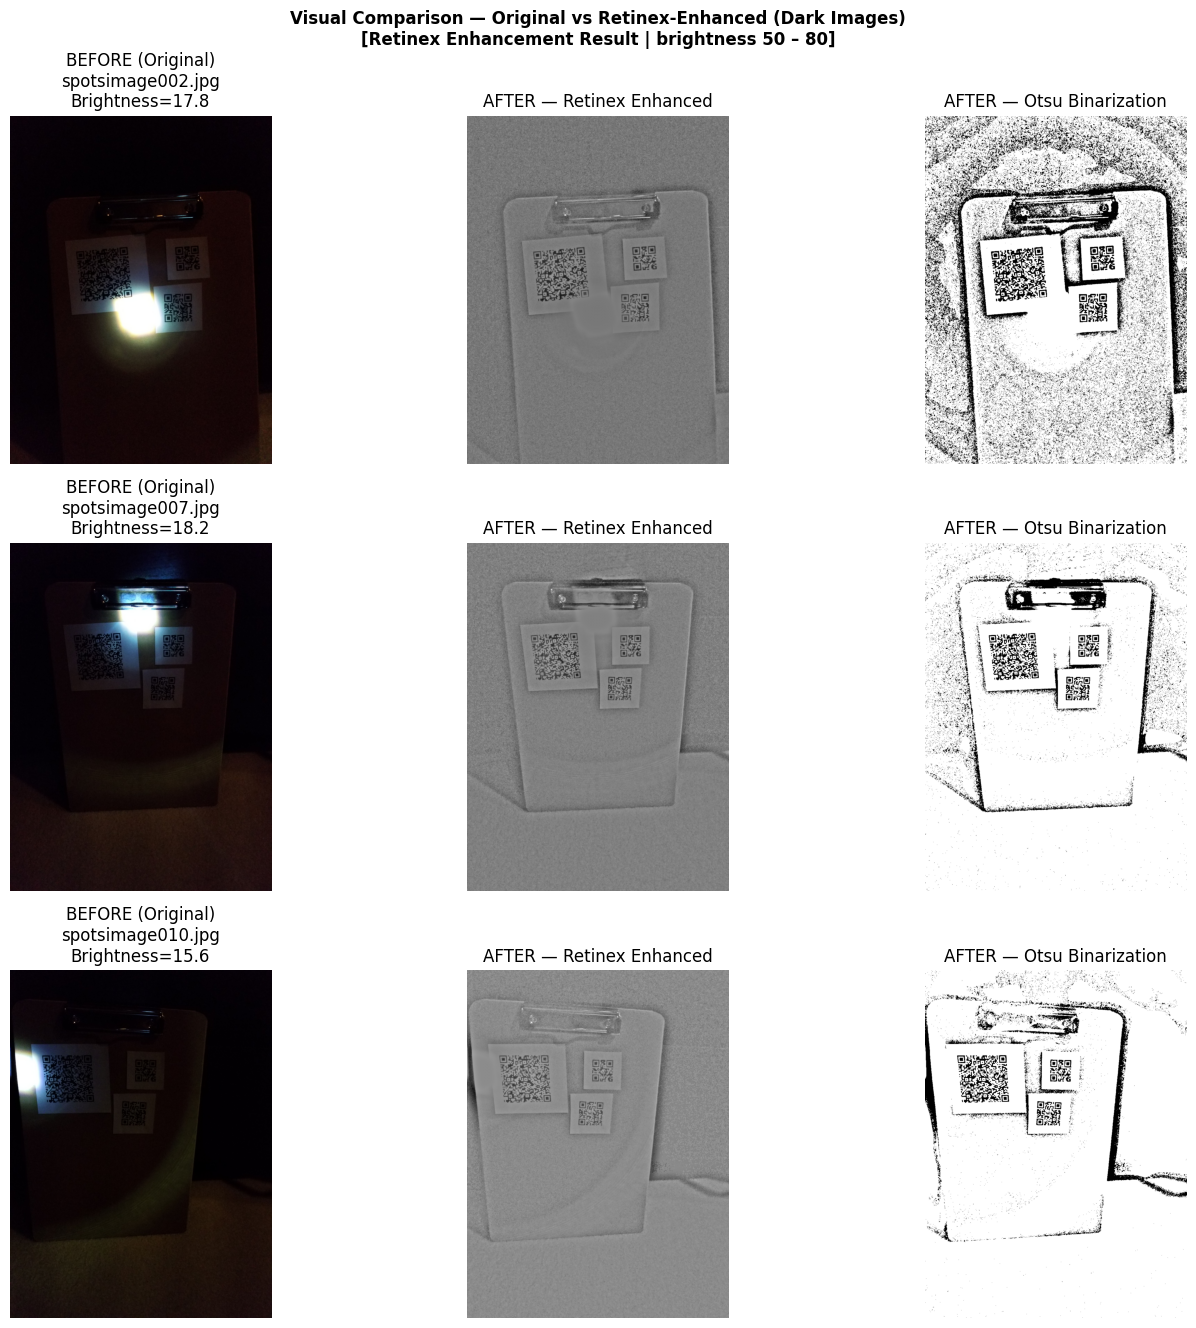

Saved: comparison_retinex.png (3 examples)


In [19]:
# ============================================================
# VISUAL COMPARISON — Original vs Retinex (dark images)
# Report ref: Section 4.3.3, Retinex Enhancement Result
# Fixed images: shadowsimage002, spotsimage007, spotsimage010
# ============================================================
# Run BEFORE the CLAHE figure cell
# ============================================================

retinex_examples = []

specific_files = [
    "spotsimage002.jpg",
    "spotsimage007.jpg",
    "spotsimage010.jpg",
]

for file in specific_files:
    path = os.path.join(FOLDER_PATH, file)
    img  = load_image(path)
    if img is None:
        print(f"Not found: {file}")
        continue
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = float(np.mean(gray))
    retinex_examples.append((file, img, brightness))


if retinex_examples:
    n   = len(retinex_examples)
    fig, axes = plt.subplots(n, 3, figsize=(15, 4.5 * n))
    if n == 1:
        axes = [axes]   # make iterable

    fig.suptitle(
        "Visual Comparison — Original vs Retinex-Enhanced (Dark Images)\n"
        "[Retinex Enhancement Result | brightness 50 – 80]",
        fontsize=12, fontweight="bold"
    )

    for i, (fname, img, brightness) in enumerate(retinex_examples):
        gray        = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        retinex_out = simple_retinex(gray, sigma=15)
        _, otsu_out = cv2.threshold(retinex_out, 0, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        axes[i][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f"BEFORE (Original)\n{fname}\nBrightness={brightness:.1f}")
        axes[i][0].axis("off")

        axes[i][1].imshow(retinex_out, cmap="gray")
        axes[i][1].set_title("AFTER — Retinex Enhanced")
        axes[i][1].axis("off")

        axes[i][2].imshow(otsu_out, cmap="gray")
        axes[i][2].set_title("AFTER — Otsu Binarization")
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.savefig("comparison_retinex.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: comparison_retinex.png ({len(retinex_examples)} examples)")

else:
    print("No images loaded — check filenames and FOLDER_PATH.")

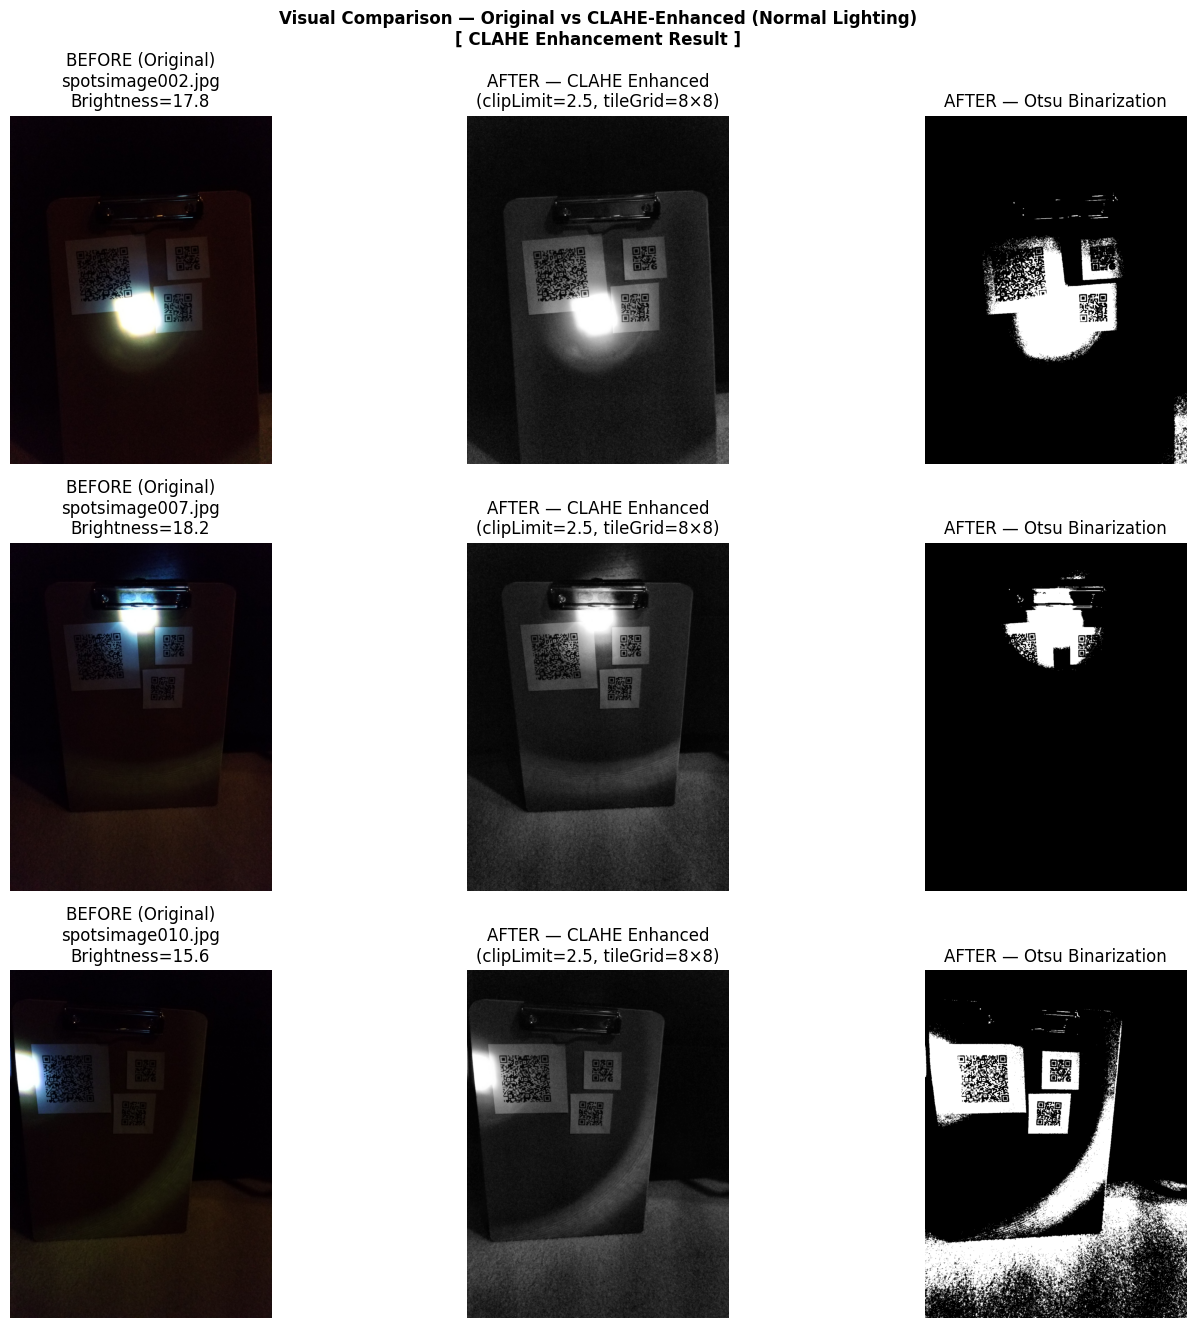

Saved: figure4_2_clahe_comparison.png (3 examples)


In [20]:
# ============================================================
# VISUAL COMPARISON — Original vs CLAHE (Normal Lighting)
# Report ref: Section 4.3.2, CLAHE Enhancement Result
# Uses same images as Figure 4.3 (retinex_examples)
# ============================================================
# Run AFTER the Retinex figure cell (retinex_examples must exist)
# ============================================================

if retinex_examples:
    n   = len(retinex_examples)
    fig, axes = plt.subplots(n, 3, figsize=(15, 4.5 * n))
    if n == 1:
        axes = [axes]   # make iterable

    fig.suptitle(
        "Visual Comparison — Original vs CLAHE-Enhanced (Normal Lighting)\n"
        "[ CLAHE Enhancement Result ]",
        fontsize=12, fontweight="bold"
    )

    clahe_obj = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))

    for i, (fname, img, brightness) in enumerate(retinex_examples):
        gray        = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        clahe_out   = clahe_obj.apply(gray)
        _, otsu_out = cv2.threshold(clahe_out, 0, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        axes[i][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f"BEFORE (Original)\n{fname}\nBrightness={brightness:.1f}")
        axes[i][0].axis("off")

        axes[i][1].imshow(clahe_out, cmap="gray")
        axes[i][1].set_title("AFTER — CLAHE Enhanced\n(clipLimit=2.5, tileGrid=8×8)")
        axes[i][1].axis("off")

        axes[i][2].imshow(otsu_out, cmap="gray")
        axes[i][2].set_title("AFTER — Otsu Binarization")
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.savefig("figure4_2_clahe_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: figure4_2_clahe_comparison.png ({len(retinex_examples)} examples)")

else:
    print("retinex_examples is empty — run the Retinex figure cell first.")

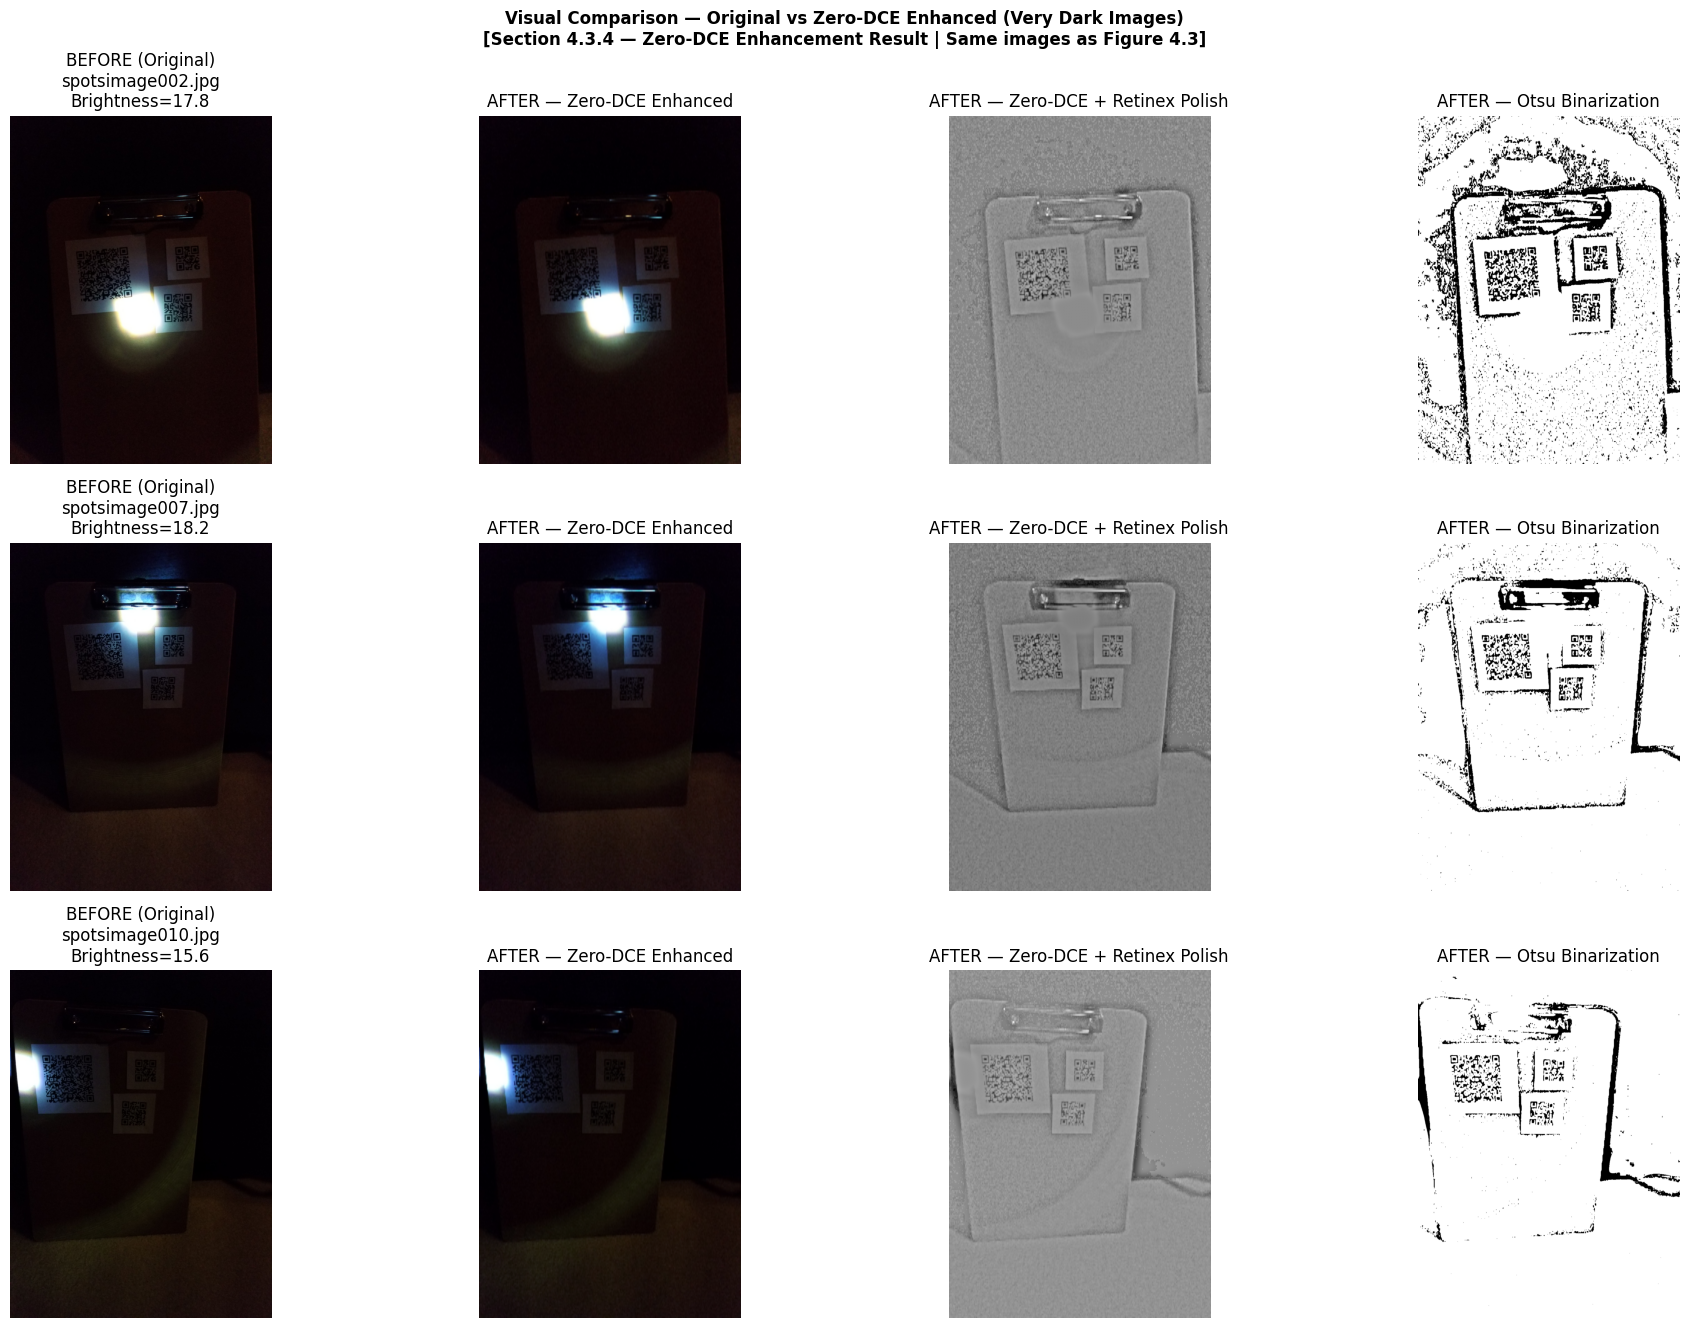

Saved: figure4_4_zerodce_comparison.png (3 examples)


In [21]:
# ============================================================
# VISUAL COMPARISON — Original vs Zero-DCE (Very Dark Images)
# Report ref: Section 4.3.4, Zero-DCE Enhancement Result
# Uses same images as Figure 4.3 (retinex_examples)
# ============================================================
# Run AFTER the Retinex figure cell (retinex_examples must exist)
# ============================================================

if retinex_examples:
    n   = len(retinex_examples)
    fig, axes = plt.subplots(n, 4, figsize=(20, 4.5 * n))
    if n == 1:
        axes = [axes]   # make iterable

    fig.suptitle(
        "Visual Comparison — Original vs Zero-DCE Enhanced (Very Dark Images)\n"
        "[Section 4.3.4 — Zero-DCE Enhancement Result | Same images as Figure 4.3]",
        fontsize=12, fontweight="bold"
    )

    for i, (fname, img, brightness) in enumerate(retinex_examples):
        # Apply Zero-DCE
        try:
            zerodce_out = apply_zero_dce(img)
        except Exception as e:
            print(f"Zero-DCE failed: {e}. Using original as fallback.")
            zerodce_out = img.copy()

        # Apply Retinex polish on top of Zero-DCE
        zdce_gray      = cv2.cvtColor(zerodce_out, cv2.COLOR_BGR2GRAY)
        retinex_polish = simple_retinex(zdce_gray, sigma=15)
        _, otsu_out    = cv2.threshold(retinex_polish, 0, 255,
                                       cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Column 1: Original
        axes[i][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f"BEFORE (Original)\n{fname}\nBrightness={brightness:.1f}")
        axes[i][0].axis("off")

        # Column 2: After Zero-DCE
        axes[i][1].imshow(cv2.cvtColor(zerodce_out, cv2.COLOR_BGR2RGB))
        axes[i][1].set_title("AFTER — Zero-DCE Enhanced")
        axes[i][1].axis("off")

        # Column 3: After Zero-DCE + Retinex polish
        axes[i][2].imshow(retinex_polish, cmap="gray")
        axes[i][2].set_title("AFTER — Zero-DCE + Retinex Polish")
        axes[i][2].axis("off")

        # Column 4: After Otsu Binarization
        axes[i][3].imshow(otsu_out, cmap="gray")
        axes[i][3].set_title("AFTER — Otsu Binarization")
        axes[i][3].axis("off")

    plt.tight_layout()
    plt.savefig("figure4_4_zerodce_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: figure4_4_zerodce_comparison.png ({len(retinex_examples)} examples)")

else:
    print("retinex_examples is empty — run the Retinex figure cell first.")

### 16.3 Preprocessing Method Distribution (from Dataset)

=== PREPROCESSING METHOD DISTRIBUTION ===
  CLAHE          :  158 images  (79.0%)
  RETINEX        :   42 images  (21.0%)


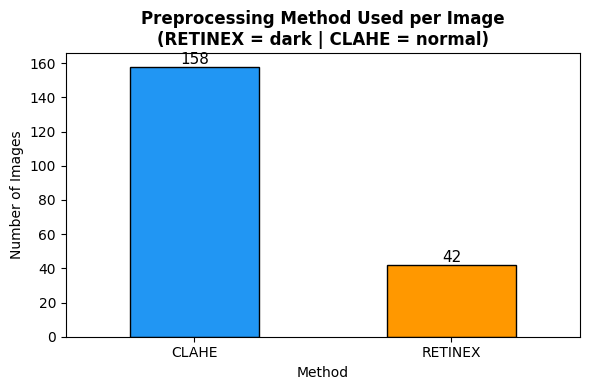

Saved: preprocessing_method_distribution.png


In [22]:
# ============================================================
# How many images used RETINEX vs CLAHE across the dataset
# ============================================================

method_counts = df["method"].value_counts()

print("=== PREPROCESSING METHOD DISTRIBUTION ===")
for method, count in method_counts.items():
    pct = count / len(df) * 100
    print(f"  {method:15s}: {count:4d} images  ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
method_counts.plot(kind="bar", ax=ax, color=["#2196F3", "#FF9800"], edgecolor="black")
ax.set_title("Preprocessing Method Used per Image\n(RETINEX = dark | CLAHE = normal)",
             fontweight="bold")
ax.set_xlabel("Method")
ax.set_ylabel("Number of Images")
ax.set_xticklabels(method_counts.index, rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig("preprocessing_method_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: preprocessing_method_distribution.png")

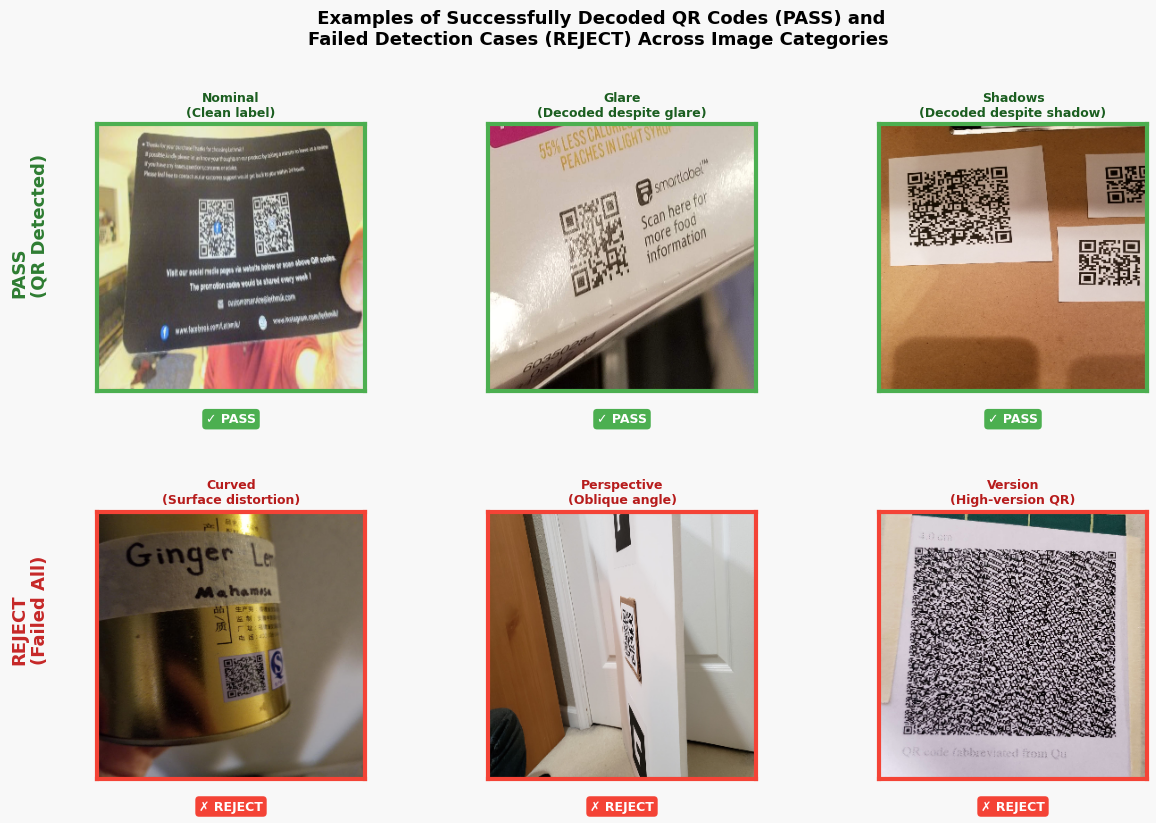

Saved: figure4_6_pass_vs_reject.png


In [23]:
# ============================================================
# FIGURE 4.6 — PASS vs REJECT Visual Examples
# Copy and paste this as a new cell in your notebook
# evalution_AI_with_visual_comparison.ipynb
# ============================================================
# Run AFTER the main evaluation loop (after df is created)
# ============================================================

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os


# ── CONFIRMED PASS images (QR successfully decoded) ──────────
pass_examples = [
    ("nominalimage001.jpg",      "Nominal\n(Clean label)"),
    ("glareimage002.jpg",        "Glare\n(Decoded despite glare)"),
    ("shadowsimage002.jpg",      "Shadows\n(Decoded despite shadow)"),
]

# ── CONFIRMED REJECT images (FAILED_ALL — not decoded) ───────
reject_examples = [
    ("curvedimage036.jpg",       "Curved\n(Surface distortion)"),
    ("perspectiveimage015.jpg",  "Perspective\n(Oblique angle)"),
    ("versionimage003.jpg",      "Version\n(High-version QR)"),
]

# ── Helper: load + resize image ───────────────────────────────
def load_and_resize(fname, size=(300, 300)):
    path = os.path.join(FOLDER_PATH, fname)
    img = cv2.imread(path)
    if img is None:
        # Return blank placeholder if file not found
        blank = np.ones((size[1], size[0], 3), dtype=np.uint8) * 200
        cv2.putText(blank, "Not found", (20, size[1]//2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (100,100,100), 1)
        return blank
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

# ── Build figure ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.patch.set_facecolor('#F8F8F8')

# Row labels
fig.text(0.01, 0.75, 'PASS\n(QR Detected)', fontsize=13, fontweight='bold',
         color='#2E7D32', va='center', ha='left', rotation=90)
fig.text(0.01, 0.27, 'REJECT\n(Failed All)', fontsize=13, fontweight='bold',
         color='#C62828', va='center', ha='left', rotation=90)

# PASS row
for col, (fname, label) in enumerate(pass_examples):
    ax = axes[0, col]
    img = load_and_resize(fname)
    ax.imshow(img)
    ax.set_title(label, fontsize=9, color='#1B5E20', fontweight='bold', pad=6)
    # Green border
    for spine in ax.spines.values():
        spine.set_edgecolor('#4CAF50')
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])
    # PASS badge
    ax.text(0.5, -0.08, '✓ PASS', transform=ax.transAxes,
            fontsize=9, color='white', fontweight='bold',
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#4CAF50', edgecolor='none'))

# REJECT row
for col, (fname, label) in enumerate(reject_examples):
    ax = axes[1, col]
    img = load_and_resize(fname)
    ax.imshow(img)
    ax.set_title(label, fontsize=9, color='#B71C1C', fontweight='bold', pad=6)
    # Red border
    for spine in ax.spines.values():
        spine.set_edgecolor('#F44336')
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])
    # REJECT badge
    ax.text(0.5, -0.08, '✗ REJECT', transform=ax.transAxes,
            fontsize=9, color='white', fontweight='bold',
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#F44336', edgecolor='none'))

# Title and caption
fig.suptitle(
    ' Examples of Successfully Decoded QR Codes (PASS) and\n'
    'Failed Detection Cases (REJECT) Across Image Categories',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout(rect=[0.04, 0.0, 1.0, 1.0])
plt.subplots_adjust(hspace=0.45, wspace=0.15)

# ── Save ──────────────────────────────────────────────────────
save_path = "figure4_6_pass_vs_reject.png"
plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {save_path}")

C:\Users\A S U S\AppData\Local\Temp\ipykernel_20488\1106683063.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(blur_by_cat.index, rotation=35, ha='right', fontsize=9)


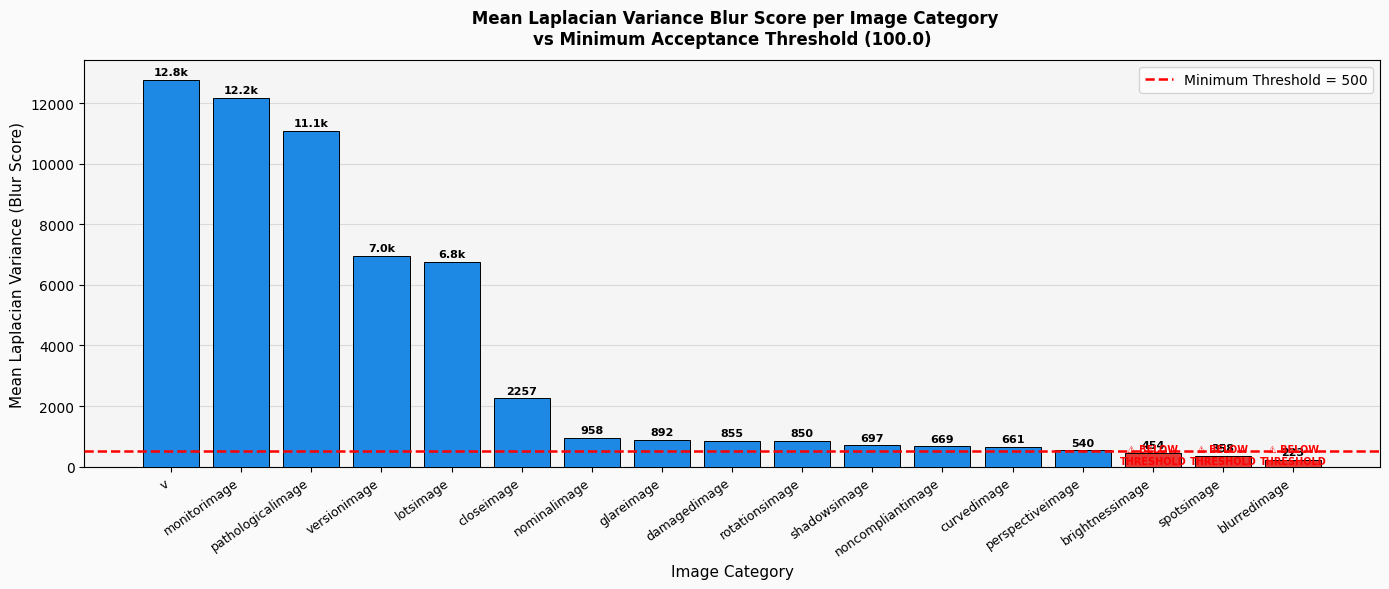

Saved: figure4_7_blur_per_category.png


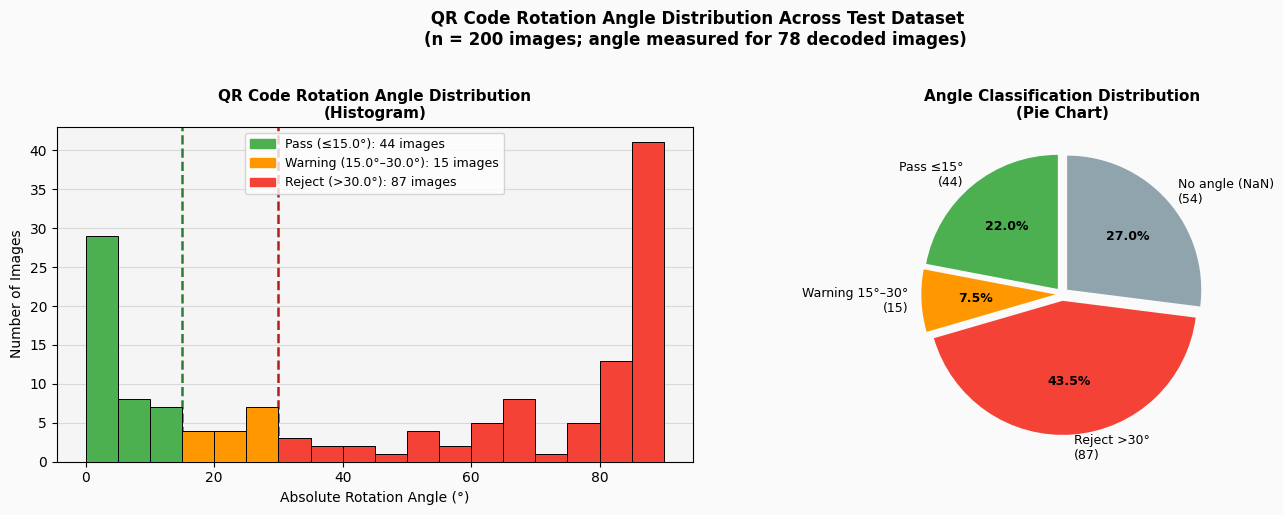

Saved: figure4_8_angle_distribution.png


In [24]:
# ============================================================
# FIGURE 4.7 — Mean Blur Score per Category vs Threshold
# FIGURE 4.8 — Angle Distribution Histogram
# Copy and paste each block as a NEW CELL in your notebook
# Run AFTER the main evaluation loop (after df is created)
# ============================================================


# ============================================================
# CELL 1 — Figure 4.7: Mean Blur Score per Category
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Extract category from filename
df['category'] = df['file'].str.extract(r'^([a-zA-Z]+)')

# Compute mean blur per category
blur_by_cat = df.groupby('category')['blur'].mean().sort_values(ascending=False)

BLUR_THRESHOLD = 500  # your defined threshold

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')

colors = ['#E53935' if v < BLUR_THRESHOLD else '#1E88E5' for v in blur_by_cat.values]
bars = ax.bar(blur_by_cat.index, blur_by_cat.values, color=colors, edgecolor='black', linewidth=0.7, zorder=3)

# Threshold line
ax.axhline(y=BLUR_THRESHOLD, color='red', linestyle='--', linewidth=1.8,
           label=f'Minimum Threshold = {BLUR_THRESHOLD}', zorder=4)

# Value labels on bars
for bar, val in zip(bars, blur_by_cat.values):
    label = f'{val:.0f}' if val < 5000 else f'{val/1000:.1f}k'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            label, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title(' Mean Laplacian Variance Blur Score per Image Category\nvs Minimum Acceptance Threshold (500.0)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Image Category', fontsize=11)
ax.set_ylabel('Mean Laplacian Variance (Blur Score)', fontsize=11)
ax.set_xticklabels(blur_by_cat.index, rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_facecolor('#F5F5F5')

# Annotation for below-threshold bars
for bar, val in zip(bars, blur_by_cat.values):
    if val < BLUR_THRESHOLD:
        ax.text(bar.get_x() + bar.get_width()/2, 20,
                '⚠ BELOW\nTHRESHOLD', ha='center', va='bottom',
                fontsize=7, color='red', fontweight='bold')

plt.tight_layout()
save_path = "figure4_7_blur_per_category.png"
plt.savefig(save_path, dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


# ============================================================
# CELL 2 — Figure 4.8: Angle Distribution Histogram
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Get absolute angle values (drop NaN)
angles = df['angle'].dropna().abs()

PASS_MAX   = 15.0
REJECT_MIN = 30.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')

# --- Left plot: Histogram with colour zones ---
ax1 = axes[0]
bins = np.arange(0, 95, 5)

# Colour each bar by zone
n, bin_edges, patches = ax1.hist(angles, bins=bins, edgecolor='black', linewidth=0.7, zorder=3)
for patch, left_edge in zip(patches, bin_edges[:-1]):
    if left_edge < PASS_MAX:
        patch.set_facecolor('#4CAF50')   # green — PASS
    elif left_edge < REJECT_MIN:
        patch.set_facecolor('#FF9800')   # orange — WARNING
    else:
        patch.set_facecolor('#F44336')   # red — REJECT

# Threshold lines
ax1.axvline(x=PASS_MAX,   color='#2E7D32', linestyle='--', linewidth=1.8, label=f'Pass threshold ({PASS_MAX}°)')
ax1.axvline(x=REJECT_MIN, color='#B71C1C', linestyle='--', linewidth=1.8, label=f'Reject threshold ({REJECT_MIN}°)')

# Legend patches
pass_patch    = mpatches.Patch(color='#4CAF50', label=f'Pass (≤{PASS_MAX}°): {sum(angles <= PASS_MAX)} images')
warn_patch    = mpatches.Patch(color='#FF9800', label=f'Warning ({PASS_MAX}°–{REJECT_MIN}°): {sum((angles > PASS_MAX) & (angles <= REJECT_MIN))} images')
reject_patch  = mpatches.Patch(color='#F44336', label=f'Reject (>{REJECT_MIN}°): {sum(angles > REJECT_MIN)} images')
ax1.legend(handles=[pass_patch, warn_patch, reject_patch], fontsize=9, loc='upper center')

ax1.set_title('QR Code Rotation Angle Distribution\n(Histogram)', fontweight='bold', fontsize=11)
ax1.set_xlabel('Absolute Rotation Angle (°)', fontsize=10)
ax1.set_ylabel('Number of Images', fontsize=10)
ax1.grid(axis='y', alpha=0.4)
ax1.set_facecolor('#F5F5F5')

# --- Right plot: Pie chart of Pass / Warning / Reject ---
ax2 = axes[1]
pass_count   = sum(angles <= PASS_MAX)
warn_count   = sum((angles > PASS_MAX) & (angles <= REJECT_MIN))
reject_count = sum(angles > REJECT_MIN)
nan_count    = df['angle'].isna().sum()

sizes  = [pass_count, warn_count, reject_count, nan_count]
labels = [f'Pass ≤15°\n({pass_count})',
          f'Warning 15°–30°\n({warn_count})',
          f'Reject >30°\n({reject_count})',
          f'No angle (NaN)\n({nan_count})']
colors = ['#4CAF50', '#FF9800', '#F44336', '#90A4AE']
explode = [0.05, 0.05, 0.05, 0.05]

wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=colors,
                                    explode=explode, autopct='%1.1f%%',
                                    startangle=90, textprops={'fontsize': 9})
for at in autotexts:
    at.set_fontweight('bold')

ax2.set_title('Angle Classification Distribution\n(Pie Chart)', fontweight='bold', fontsize=11)

fig.suptitle(' QR Code Rotation Angle Distribution Across Test Dataset\n'
             '(n = 200 images; angle measured for 78 decoded images)',
             fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
save_path = "figure4_8_angle_distribution.png"
plt.savefig(save_path, dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")